# Candidate SSE detection on a sparse temporal cluster-transition graph

This notebook demonstrates a robust, statistically defensible workflow using **dummy data**.

The graph represents clusters of genetically similar COVID-19 genomes sampled in overlapping epidemic windows. Directed edges connect clusters in adjacent windows, with edge weights representing shared sequences.

The goal is not to prove that a node is a true superspreading event. Instead, we rank **candidate SSE-like nodes** using:

- sampling-adjusted excess cluster size;
- outgoing transition structure;
- downstream burden;
- temporal compactness;
- socio-geodemographic coherence;
- a stratified permutation null model.

In [1]:
import math
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Tuple

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

RANDOM_SEED = 42
N_WINDOWS = 8
N_CLUSTERS_PER_WINDOW = (10, 18)
N_PERMUTATIONS = 250
OUTPUT_DIR = Path("sse_dummy_outputs_notebook")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

In [2]:
@dataclass
class SimulationConfig:
    seed: int = RANDOM_SEED
    n_windows: int = N_WINDOWS
    n_clusters_min: int = N_CLUSTERS_PER_WINDOW[0]
    n_clusters_max: int = N_CLUSTERS_PER_WINDOW[1]
    sse_nodes: Tuple[Tuple[int, int], ...] = ((2, 3), (4, 7))


def entropy_from_counts(counts: Iterable[int | float]) -> float:
    arr = np.asarray(list(counts), dtype=float)
    arr = arr[arr > 0]
    if arr.size == 0:
        return 0.0
    p = arr / arr.sum()
    return float(-(p * np.log(p)).sum())


def normalise_series(s: pd.Series) -> pd.Series:
    sd = s.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / sd


def empirical_upper_tail_p(obs: float, null_values: np.ndarray) -> float:
    return float((1 + np.sum(null_values >= obs)) / (len(null_values) + 1))

## 1. Simulate dummy cluster nodes

Each row is a cluster node in a time window. The dummy attributes mimic the sort of node table you described: cluster size, region, lineage, dominant setting, sampling intensity and socio-demographic coherence measures.

A few nodes are deliberately injected as SSE-like examples so that we can check whether the method recovers them.

In [3]:
def simulate_dummy_clusters(config: SimulationConfig) -> pd.DataFrame:
    rng = np.random.default_rng(config.seed)
    regions = ["Greater Glasgow", "Lothian", "Tayside", "Grampian", "Lanarkshire"]
    lineages = ["B.1.1.7", "AY.4", "BA.1", "BA.2"]
    settings = ["community", "workplace", "care_home", "university", "hospital"]

    rows = []
    node_id = 0

    for window in range(config.n_windows):
        n_clusters = int(rng.integers(config.n_clusters_min, config.n_clusters_max + 1))

        for idx in range(n_clusters):
            node = f"w{window}_c{idx}"
            region = rng.choice(regions, p=[0.28, 0.24, 0.16, 0.16, 0.16])
            lineage = rng.choice(lineages, p=[0.25, 0.30, 0.25, 0.20])
            setting = rng.choice(settings, p=[0.58, 0.14, 0.08, 0.12, 0.08])

            region_multiplier = {
                "Greater Glasgow": 1.40,
                "Lothian": 1.25,
                "Tayside": 0.90,
                "Grampian": 0.80,
                "Lanarkshire": 0.95,
            }[region]
            time_multiplier = 0.75 + 0.12 * window + rng.normal(0, 0.04)
            sampling_intensity = max(0.05, region_multiplier * time_multiplier)

            size = int(1 + rng.negative_binomial(n=1.2, p=0.55))
            is_injected_sse = (window, idx) in config.sse_nodes

            if is_injected_sse:
                size = int(rng.integers(25, 45))
                setting = rng.choice(["workplace", "university", "care_home"])
                sampling_intensity *= rng.uniform(0.9, 1.2)

            temporal_span_days = int(max(1, rng.gamma(shape=2.0, scale=2.0)))
            if is_injected_sse:
                temporal_span_days = int(rng.integers(1, 4))

            location_homogeneity = np.clip(rng.beta(5, 2), 0, 1)
            age_homogeneity = np.clip(rng.beta(3, 3), 0, 1)
            deprivation_homogeneity = np.clip(rng.beta(2.5, 3.5), 0, 1)
            setting_enrichment = np.clip(rng.beta(2, 5), 0, 1)

            if is_injected_sse:
                location_homogeneity = np.clip(rng.normal(0.92, 0.04), 0, 1)
                age_homogeneity = np.clip(rng.normal(0.78, 0.08), 0, 1)
                deprivation_homogeneity = np.clip(rng.normal(0.65, 0.10), 0, 1)
                setting_enrichment = np.clip(rng.normal(0.90, 0.05), 0, 1)

            rows.append({
                "node": node,
                "window": window,
                "cluster_index": idx,
                "node_number": node_id,
                "cluster_size": size,
                "region": region,
                "lineage": lineage,
                "dominant_setting": setting,
                "sampling_intensity": sampling_intensity,
                "temporal_span_days": temporal_span_days,
                "location_homogeneity": location_homogeneity,
                "age_homogeneity": age_homogeneity,
                "deprivation_homogeneity": deprivation_homogeneity,
                "setting_enrichment": setting_enrichment,
                "injected_sse": is_injected_sse,
            })
            node_id += 1

    nodes = pd.DataFrame(rows)

    nodes["expected_size_sampling"] = (
        nodes.groupby(["window", "lineage", "region"])["cluster_size"]
        .transform("mean")
        .fillna(nodes["cluster_size"].mean())
    )

    global_mean = nodes["cluster_size"].mean()
    nodes["expected_size_sampling"] = (
        0.5 * nodes["expected_size_sampling"]
        + 0.5 * global_mean * nodes["sampling_intensity"] / nodes["sampling_intensity"].mean()
    ).clip(lower=0.5)

    return nodes


config = SimulationConfig()
nodes = simulate_dummy_clusters(config)
nodes.head()

,node,window,cluster_index,node_number,cluster_size,region,lineage,dominant_setting,sampling_intensity,temporal_span_days,location_homogeneity,age_homogeneity,deprivation_homogeneity,setting_enrichment,injected_sse,expected_size_sampling
0,w0_c0,0,0,0,1,Lothian,BA.2,workplace,0.839948,3,0.795863,0.513927,0.567221,0.499632,False,1.669519
1,w0_c1,0,1,1,1,Lothian,B.1.1.7,community,0.959041,7,0.536745,0.544018,0.411548,0.221563,False,1.549894
2,w0_c2,0,2,2,5,Grampian,AY.4,community,0.591195,5,0.565466,0.430126,0.491498,0.313299,False,3.147201
3,w0_c3,0,3,3,1,Greater Glasgow,B.1.1.7,care_home,1.077270,4,0.740020,0.409141,0.151692,0.398901,False,1.929324
4,w0_c4,0,4,4,4,Lanarkshire,AY.4,community,0.729008,3,0.685890,0.627998,0.321160,0.095990,False,2.798069


## 2. Simulate transition edges between adjacent windows

The graph is intentionally sparse. Many clusters are singletons or isolated. Edges represent the number of shared sequences between clusters in adjacent windows.

In [4]:
def simulate_transition_edges(nodes: pd.DataFrame, config: SimulationConfig) -> pd.DataFrame:
    rng = np.random.default_rng(config.seed + 1)
    edges = []

    for window in range(config.n_windows - 1):
        current = nodes[nodes["window"] == window].copy()
        nxt = nodes[nodes["window"] == window + 1].copy()

        for _, src in current.iterrows():
            base_prob = 0.08
            size_effect = min(0.25, src["cluster_size"] / 150)
            p_has_edge = 0.95 if src["injected_sse"] else base_prob + size_effect

            if rng.random() > p_has_edge:
                continue

            if src["injected_sse"]:
                n_targets = int(rng.integers(3, 7))
            else:
                n_targets = int(rng.choice([1, 1, 1, 2, 3], p=[0.55, 0.20, 0.10, 0.10, 0.05]))

            target_scores = np.ones(len(nxt), dtype=float)
            target_scores += (nxt["lineage"].values == src["lineage"]) * 3.0
            target_scores += (nxt["region"].values == src["region"]) * 2.0
            target_scores += nxt["cluster_size"].values / max(1, nxt["cluster_size"].max())
            target_scores = target_scores / target_scores.sum()

            target_indices = rng.choice(
                np.arange(len(nxt)),
                size=min(n_targets, len(nxt)),
                replace=False,
                p=target_scores,
            )

            for target_idx in target_indices:
                tgt = nxt.iloc[target_idx]

                if src["injected_sse"]:
                    weight = int(rng.integers(3, min(15, src["cluster_size"]) + 1))
                else:
                    weight = int(rng.choice([1, 1, 1, 2, 3, 4], p=[0.45, 0.25, 0.12, 0.10, 0.05, 0.03]))

                weight = max(1, min(weight, int(src["cluster_size"]), int(tgt["cluster_size"])))

                edges.append({
                    "source": src["node"],
                    "target": tgt["node"],
                    "source_window": int(src["window"]),
                    "target_window": int(tgt["window"]),
                    "weight": weight,
                })

    return pd.DataFrame(edges)


edges = simulate_transition_edges(nodes, config)
edges.head()

,source,target,source_window,target_window,weight
0,w0_c1,w1_c13,0,1,1
1,w1_c2,w2_c10,1,2,2
2,w1_c9,w2_c8,1,2,1
3,w1_c13,w2_c7,1,2,1
4,w2_c3,w3_c1,2,3,3


## 3. Build graph and compute node features

This is the feature table used for ranking. In a real dataset, you would replace the simulated node and edge tables with your own data and keep the rest of the pipeline mostly unchanged.

In [5]:
def build_transition_graph(nodes: pd.DataFrame, edges: pd.DataFrame) -> nx.DiGraph:
    G = nx.DiGraph()
    for _, row in nodes.iterrows():
        G.add_node(row["node"], **row.to_dict())
    for _, row in edges.iterrows():
        G.add_edge(row["source"], row["target"], weight=float(row["weight"]))
    return G


def compute_node_features(nodes: pd.DataFrame, edges: pd.DataFrame) -> pd.DataFrame:
    features = nodes.copy()

    outgoing = edges.groupby("source").agg(
        outgoing_weight=("weight", "sum"),
        weighted_outdegree=("target", "nunique"),
        outgoing_entropy=("weight", entropy_from_counts),
    ) if not edges.empty else pd.DataFrame()

    incoming = edges.groupby("target").agg(
        incoming_weight=("weight", "sum"),
        weighted_indegree=("source", "nunique"),
    ) if not edges.empty else pd.DataFrame()

    if not outgoing.empty:
        features = features.merge(outgoing, left_on="node", right_index=True, how="left")
    if not incoming.empty:
        features = features.merge(incoming, left_on="node", right_index=True, how="left")

    if not edges.empty:
        target_sizes = features[["node", "cluster_size"]].rename(
            columns={"node": "target", "cluster_size": "target_cluster_size"}
        )
        downstream = (
            edges.merge(target_sizes, on="target", how="left")
            .groupby("source")
            .agg(downstream_burden=("target_cluster_size", "sum"))
        )
        features = features.merge(downstream, left_on="node", right_index=True, how="left")

    for col in [
        "incoming_weight", "outgoing_weight", "weighted_outdegree",
        "weighted_indegree", "outgoing_entropy", "downstream_burden"
    ]:
        if col not in features.columns:
            features[col] = 0
        features[col] = features[col].fillna(0)

    features["sampling_adjusted_excess_size"] = (
        features["cluster_size"] - features["expected_size_sampling"]
    ) / np.sqrt(features["expected_size_sampling"].clip(lower=0.5))

    features["temporal_compactness"] = 1 / (1 + features["temporal_span_days"])

    features["epi_coherence"] = (
        0.30 * features["location_homogeneity"]
        + 0.20 * features["age_homogeneity"]
        + 0.15 * features["deprivation_homogeneity"]
        + 0.25 * features["setting_enrichment"]
        + 0.10 * features["temporal_compactness"]
    )

    score_components = [
        "sampling_adjusted_excess_size",
        "outgoing_weight",
        "weighted_outdegree",
        "outgoing_entropy",
        "downstream_burden",
        "epi_coherence",
    ]

    for col in score_components:
        features[f"z_{col}"] = normalise_series(features[col])

    features["raw_sse_score"] = (
        1.25 * features["z_sampling_adjusted_excess_size"]
        + 1.10 * features["z_outgoing_weight"]
        + 0.85 * features["z_weighted_outdegree"]
        + 0.50 * features["z_outgoing_entropy"]
        + 1.00 * features["z_downstream_burden"]
        + 0.80 * features["z_epi_coherence"]
    )

    return features


G = build_transition_graph(nodes, edges)
features = compute_node_features(nodes, edges)

features.sort_values("raw_sse_score", ascending=False).head(10)

,node,window,cluster_index,node_number,cluster_size,region,lineage,dominant_setting,sampling_intensity,temporal_span_days,...,sampling_adjusted_excess_size,temporal_compactness,epi_coherence,z_sampling_adjusted_excess_size,z_outgoing_weight,z_weighted_outdegree,z_outgoing_entropy,z_downstream_burden,z_epi_coherence,raw_sse_score
29,w2_c3,2,3,29,41,Lothian,B.1.1.7,care_home,1.300163,1,...,4.074265,0.500000,0.847670,3.674252,9.175271,7.608002,8.242122,8.944629,4.123672,37.517042
62,w4_c7,4,7,62,41,Lanarkshire,B.1.1.7,care_home,1.379141,2,...,8.365340,0.333333,0.760707,7.400576,4.502679,6.043740,6.332501,4.076804,3.160904,29.112624
23,w1_c13,1,13,23,5,Lanarkshire,BA.2,community,0.762447,5,...,0.911952,0.166667,0.547695,0.928133,0.497601,1.350954,-0.134950,0.425935,0.802662,3.856426
1,w0_c1,0,1,1,1,Lothian,B.1.1.7,community,0.959041,7,...,-0.441701,0.125000,0.399450,-0.247365,0.497601,1.350954,-0.134950,2.859847,-0.838549,3.507999
12,w1_c2,1,2,12,2,Lanarkshire,BA.1,university,0.815230,5,...,0.353080,0.166667,0.418601,0.442815,1.165114,1.350954,-0.134950,1.034413,-0.626527,3.449170
39,w3_c1,3,1,39,3,Lothian,BA.2,university,1.339760,2,...,0.019345,0.333333,0.568639,0.153002,0.497601,1.350954,-0.134950,0.425935,1.034537,3.073014
19,w1_c9,1,9,19,2,Lothian,B.1.1.7,community,0.995930,6,...,-0.062442,0.142857,0.466709,0.081980,0.497601,1.350954,-0.134950,0.425935,-0.093932,2.081460
51,w3_c13,3,13,51,6,Lanarkshire,BA.2,community,1.081931,1,...,0.887557,0.500000,0.632528,0.906948,-0.169912,-0.213308,-0.134950,-0.182543,1.741840,1.908923
57,w4_c2,4,2,57,8,Lothian,B.1.1.7,care_home,1.501756,2,...,1.894190,0.333333,0.493565,1.781098,-0.169912,-0.213308,-0.134950,-0.182543,0.203395,1.770854
46,w3_c8,3,8,46,4,Grampian,AY.4,hospital,0.859171,1,...,1.222547,0.500000,0.552126,1.197850,-0.169912,-0.213308,-0.134950,-0.182543,0.851720,1.560454


## 4. Stratified permutation null model

The permutation null compares each node against similar temporal, lineage and regional contexts. This avoids simply rewarding nodes from heavily sequenced windows or regions.

In [6]:
def permute_features_within_strata(
    features: pd.DataFrame,
    rng: np.random.Generator,
    strata_cols=("window", "lineage", "region"),
) -> pd.DataFrame:
    perm = features.copy()

    cols_to_permute = [
        "cluster_size",
        "expected_size_sampling",
        "sampling_adjusted_excess_size",
        "temporal_span_days",
        "temporal_compactness",
        "location_homogeneity",
        "age_homogeneity",
        "deprivation_homogeneity",
        "setting_enrichment",
        "epi_coherence",
    ]

    def choose_strata(df: pd.DataFrame) -> pd.Series:
        key3 = df[list(strata_cols)].astype(str).agg("|".join, axis=1)
        counts3 = key3.map(key3.value_counts())
        key2 = df[["window", "lineage"]].astype(str).agg("|".join, axis=1)
        counts2 = key2.map(key2.value_counts())
        key1 = df[["window"]].astype(str).agg("|".join, axis=1)
        return np.where(counts3 >= 4, key3, np.where(counts2 >= 4, key2, key1))

    perm["_perm_stratum"] = choose_strata(perm)

    for _, idx in perm.groupby("_perm_stratum").groups.items():
        idx = list(idx)
        if len(idx) <= 1:
            continue
        for col in cols_to_permute:
            perm.loc[idx, col] = rng.permutation(perm.loc[idx, col].values)

    score_components = [
        "sampling_adjusted_excess_size",
        "outgoing_weight",
        "weighted_outdegree",
        "outgoing_entropy",
        "downstream_burden",
        "epi_coherence",
    ]

    for col in score_components:
        perm[f"z_{col}"] = normalise_series(perm[col])

    perm["raw_sse_score"] = (
        1.25 * perm["z_sampling_adjusted_excess_size"]
        + 1.10 * perm["z_outgoing_weight"]
        + 0.85 * perm["z_weighted_outdegree"]
        + 0.50 * perm["z_outgoing_entropy"]
        + 1.00 * perm["z_downstream_burden"]
        + 0.80 * perm["z_epi_coherence"]
    )

    return perm.drop(columns=["_perm_stratum"])


def add_permutation_p_values(features, n_permutations=N_PERMUTATIONS, seed=RANDOM_SEED + 2):
    rng = np.random.default_rng(seed)
    null_scores = np.zeros((len(features), n_permutations))

    for b in range(n_permutations):
        perm = permute_features_within_strata(features, rng)
        null_scores[:, b] = perm["raw_sse_score"].values

    obs = features["raw_sse_score"].values
    pvals = np.array([
        empirical_upper_tail_p(obs[i], null_scores[i, :])
        for i in range(len(features))
    ])

    out = features.copy()
    out["empirical_p"] = pvals
    out["null_mean_score"] = null_scores.mean(axis=1)
    out["null_sd_score"] = null_scores.std(axis=1, ddof=0)
    out["null_adjusted_score"] = (
        out["raw_sse_score"] - out["null_mean_score"]
    ) / out["null_sd_score"].replace(0, np.nan)
    out["null_adjusted_score"] = out["null_adjusted_score"].fillna(0)

    out["candidate_class"] = "unlikely_or_uninformative"

    large_or_connected = (
        (out["cluster_size"] >= 3)
        | (out["outgoing_weight"] >= 2)
        | (out["downstream_burden"] >= 5)
    )

    high_conf = (
        large_or_connected
        & (out["empirical_p"] <= 0.05)
        & (out["sampling_adjusted_excess_size"] > 1.0)
        & ((out["outgoing_weight"] > 0) | (out["downstream_burden"] > 0))
        & (out["epi_coherence"] >= out["epi_coherence"].quantile(0.60))
    )

    possible = (
        large_or_connected
        & ~high_conf
        & (
            (out["empirical_p"] <= 0.10)
            | (
                (out["sampling_adjusted_excess_size"] > 1.5)
                & (out["epi_coherence"] >= out["epi_coherence"].quantile(0.50))
            )
            | (
                (out["outgoing_weight"] >= out["outgoing_weight"].quantile(0.90))
                & (out["downstream_burden"] >= out["downstream_burden"].quantile(0.80))
            )
        )
    )

    terminal_large = (
        (out["cluster_size"] >= out["cluster_size"].quantile(0.90))
        & (out["outgoing_weight"] == 0)
    )

    out.loc[possible, "candidate_class"] = "possible_candidate_sse"
    out.loc[terminal_large, "candidate_class"] = "large_terminal_cluster"
    out.loc[high_conf, "candidate_class"] = "high_confidence_candidate_sse"

    return out


ranked = add_permutation_p_values(features)
ranked.sort_values("null_adjusted_score", ascending=False).head(15)

,node,window,cluster_index,node_number,cluster_size,region,lineage,dominant_setting,sampling_intensity,temporal_span_days,...,z_weighted_outdegree,z_outgoing_entropy,z_downstream_burden,z_epi_coherence,raw_sse_score,empirical_p,null_mean_score,null_sd_score,null_adjusted_score,candidate_class
29,w2_c3,2,3,29,41,Lothian,B.1.1.7,care_home,1.300163,1,...,7.608002,8.242122,8.944629,4.123672,37.517042,0.063745,31.760275,2.330344,2.470351,possible_candidate_sse
46,w3_c8,3,8,46,4,Grampian,AY.4,hospital,0.859171,1,...,-0.213308,-0.134950,-0.182543,0.851720,1.560454,0.075697,-0.709570,1.032679,2.198189,large_terminal_cluster
51,w3_c13,3,13,51,6,Lanarkshire,BA.2,community,1.081931,1,...,-0.213308,-0.134950,-0.182543,1.741840,1.908923,0.031873,0.351492,0.732881,2.125079,large_terminal_cluster
62,w4_c7,4,7,62,41,Lanarkshire,B.1.1.7,care_home,1.379141,2,...,6.043740,6.332501,4.076804,3.160904,29.112624,0.071713,19.747359,4.829376,1.939229,possible_candidate_sse
23,w1_c13,1,13,23,5,Lanarkshire,BA.2,community,0.762447,5,...,1.350954,-0.134950,0.425935,0.802662,3.856426,0.023904,2.524388,0.700964,1.900293,possible_candidate_sse
48,w3_c10,3,10,48,3,Tayside,B.1.1.7,community,1.057323,5,...,-0.213308,-0.134950,-0.182543,-0.260944,-0.034108,0.047809,-1.169661,0.635957,1.785581,possible_candidate_sse
94,w6_c14,6,14,94,2,Tayside,BA.2,community,1.367348,7,...,-0.213308,-0.134950,-0.182543,-0.115840,-0.881985,0.067729,-1.825227,0.554202,1.701983,unlikely_or_uninformative
81,w6_c1,6,1,81,2,Lothian,BA.1,workplace,1.800307,7,...,-0.213308,-0.134950,-0.182543,-0.136831,-0.958889,0.131474,-1.877535,0.542579,1.693108,unlikely_or_uninformative
6,w0_c6,0,6,6,2,Lothian,BA.2,university,0.892354,1,...,-0.213308,-0.134950,-0.182543,1.747604,1.175699,0.079681,-0.552488,1.116616,1.547700,unlikely_or_uninformative
22,w1_c12,1,12,22,6,Grampian,BA.1,hospital,0.738758,11,...,-0.213308,-0.134950,-0.182543,-0.593756,1.319464,0.079681,-0.530078,1.207033,1.532305,large_terminal_cluster


## 5. Inspect and export ranked candidates

The `injected_sse` column exists only because this is simulated data. In real data, you would remove it and interpret the ranked candidates alongside epidemiological metadata.

In [7]:
cols = [
    "node", "window", "cluster_size", "region", "lineage", "dominant_setting",
    "outgoing_weight", "weighted_outdegree", "downstream_burden",
    "sampling_adjusted_excess_size", "epi_coherence",
    "raw_sse_score", "null_adjusted_score", "empirical_p",
    "candidate_class", "injected_sse"
]

ranked_view = ranked.sort_values("null_adjusted_score", ascending=False)[cols]
ranked_view.head(20)

,node,window,cluster_size,region,lineage,dominant_setting,outgoing_weight,weighted_outdegree,downstream_burden,sampling_adjusted_excess_size,epi_coherence,raw_sse_score,null_adjusted_score,empirical_p,candidate_class,injected_sse
29,w2_c3,2,41,Lothian,B.1.1.7,care_home,14.0,5.0,15.0,4.074265,0.847670,37.517042,2.470351,0.063745,possible_candidate_sse,True
46,w3_c8,3,4,Grampian,AY.4,hospital,0.0,0.0,0.0,1.222547,0.552126,1.560454,2.198189,0.075697,large_terminal_cluster,False
51,w3_c13,3,6,Lanarkshire,BA.2,community,0.0,0.0,0.0,0.887557,0.632528,1.908923,2.125079,0.031873,large_terminal_cluster,False
62,w4_c7,4,41,Lanarkshire,B.1.1.7,care_home,7.0,4.0,7.0,8.365340,0.760707,29.112624,1.939229,0.071713,possible_candidate_sse,True
23,w1_c13,1,5,Lanarkshire,BA.2,community,1.0,1.0,1.0,0.911952,0.547695,3.856426,1.900293,0.023904,possible_candidate_sse,False
48,w3_c10,3,3,Tayside,B.1.1.7,community,0.0,0.0,0.0,0.573592,0.451623,-0.034108,1.785581,0.047809,possible_candidate_sse,False
94,w6_c14,6,2,Tayside,BA.2,community,0.0,0.0,0.0,-0.314451,0.464730,-0.881985,1.701983,0.067729,unlikely_or_uninformative,False
81,w6_c1,6,2,Lothian,BA.1,workplace,0.0,0.0,0.0,-0.369829,0.462834,-0.958889,1.693108,0.131474,unlikely_or_uninformative,False
6,w0_c6,0,2,Lothian,BA.2,university,0.0,0.0,0.0,0.207829,0.633048,1.175699,1.547700,0.079681,unlikely_or_uninformative,False
22,w1_c12,1,6,Grampian,BA.1,hospital,0.0,0.0,0.0,2.065847,0.421561,1.319464,1.532305,0.079681,large_terminal_cluster,False


In [ ]:
nodes.to_csv(OUTPUT_DIR / "dummy_cluster_nodes.csv", index=False)
edges.to_csv(OUTPUT_DIR / "dummy_transition_edges.csv", index=False)
features.to_csv(OUTPUT_DIR / "node_features.csv", index=False)
ranked.to_csv(OUTPUT_DIR / "ranked_candidate_sse_nodes.csv", index=False)

OUTPUT_DIR.resolve()

## 6. Plot the graph and ranked scores

Node size reflects cluster size. High-confidence candidate nodes are labelled in the graph.

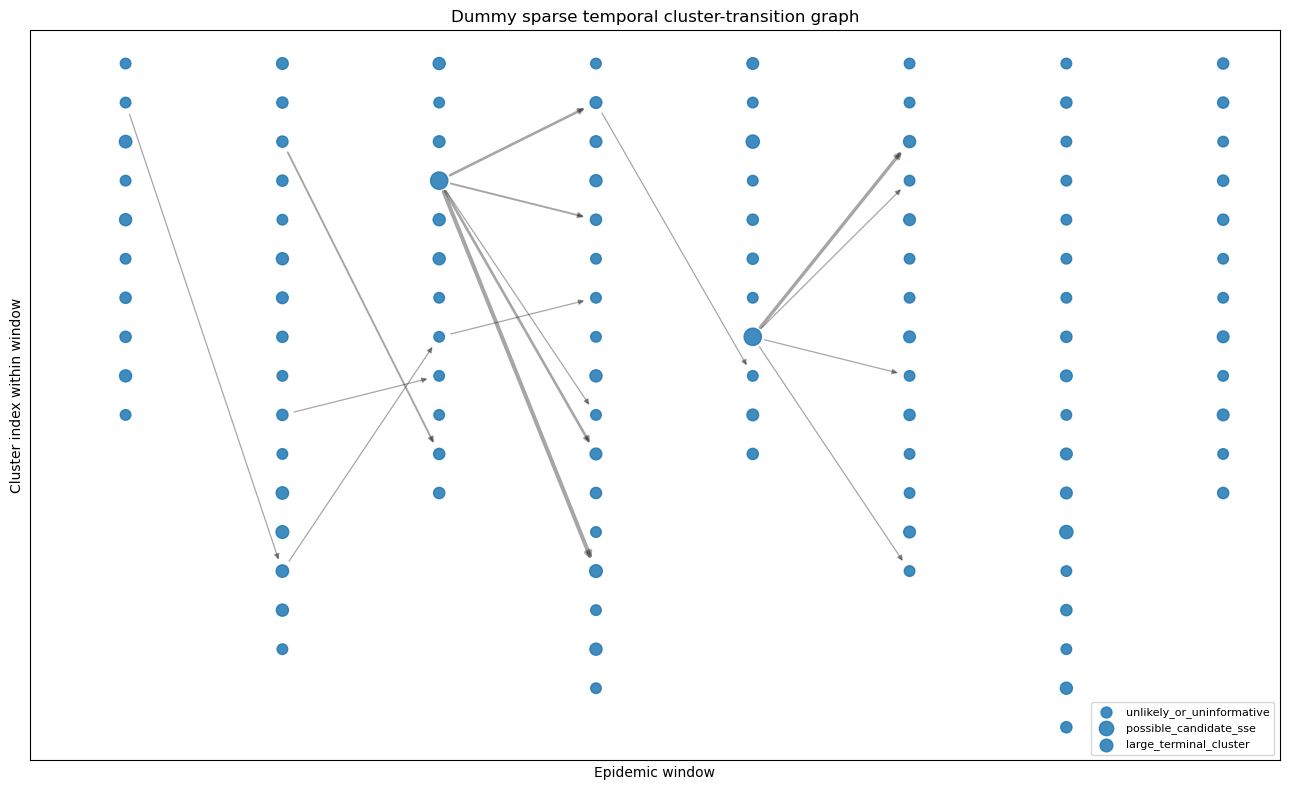

In [8]:
def plot_graph(G: nx.DiGraph, ranked: pd.DataFrame, output_dir: Path):
    pos = {node: (data["window"], -data["cluster_index"]) for node, data in G.nodes(data=True)}
    classes = ranked.set_index("node")["candidate_class"].to_dict()
    sizes = ranked.set_index("node")["cluster_size"].to_dict()
    all_nodes = list(G.nodes())

    node_sizes = [40 + 18 * math.sqrt(sizes.get(n, 1)) for n in all_nodes]

    plt.figure(figsize=(13, 8))

    for cls in ranked["candidate_class"].unique():
        nodelist = [n for n in all_nodes if classes.get(n) == cls]
        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=nodelist,
            node_size=[node_sizes[all_nodes.index(n)] for n in nodelist],
            label=cls,
            alpha=0.85,
        )

    edge_widths = [0.4 + 0.5 * G[u][v]["weight"] for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.35, arrows=True, arrowsize=8)

    labels = {n: n if classes.get(n) == "high_confidence_candidate_sse" else "" for n in all_nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

    plt.title("Dummy sparse temporal cluster-transition graph")
    plt.xlabel("Epidemic window")
    plt.ylabel("Cluster index within window")
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.savefig(output_dir / "transition_graph.png", dpi=180)
    plt.show()


plot_graph(G, ranked, OUTPUT_DIR)

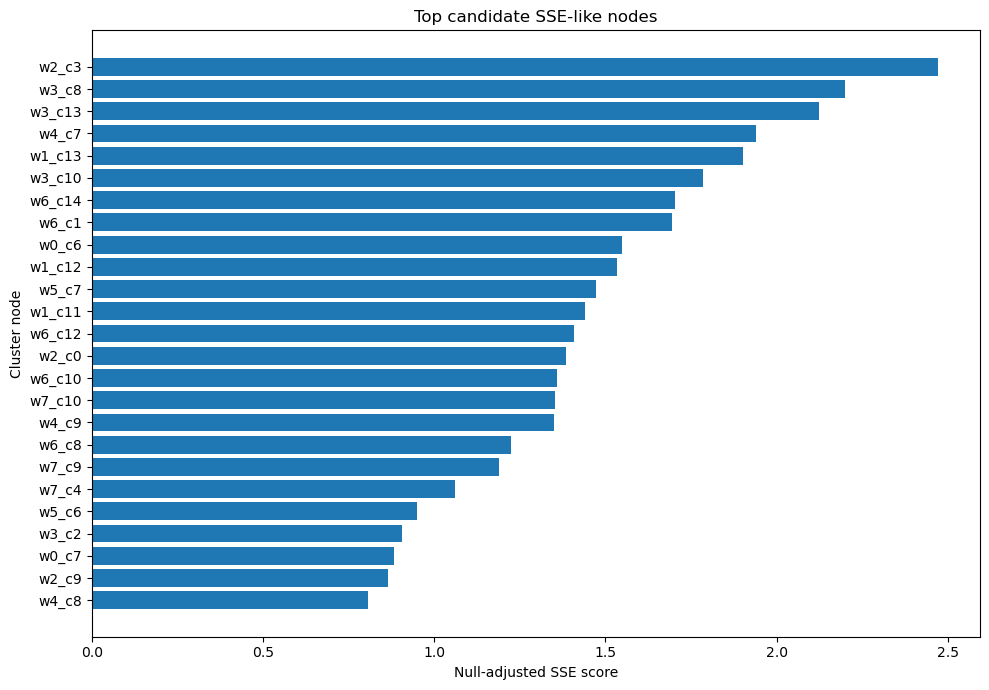

In [9]:
top = ranked.sort_values("null_adjusted_score", ascending=False).head(25).copy()
top = top.sort_values("null_adjusted_score", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top["node"], top["null_adjusted_score"])
plt.xlabel("Null-adjusted SSE score")
plt.ylabel("Cluster node")
plt.title("Top candidate SSE-like nodes")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ranked_candidate_scores.png", dpi=180)
plt.show()

## How to adapt this to your real data

Replace the dummy `nodes` and `edges` tables with your own tables.

Your node table should minimally contain:

```text
node
window
cluster_size
region or health board
lineage
sampling_intensity or sequencing denominator
temporal_span_days
socio-demographic coherence variables
```

Your edge table should minimally contain:

```text
source
target
source_window
target_window
weight
```

The most important adaptation is the sampling model. In real work, `expected_size_sampling` should ideally use case counts, sequencing proportion, lineage prevalence and region/window denominators rather than the toy estimator used here.